# Baseline de Volume de Incidentes — D+1 / D+7

Sprint 3 · Machine Learning & Artificial Intelligence · projeto de ML(Locaweb)

## 01 · Contexto e objetivo

O projeto trata a operação de incidentes de TI como uma **série temporal multidimensional**.
Esta entrega isola a camada mais simples desse problema: prever o **volume diário total de
incidentes** com dois horizontes de previsão.

$$
\text{D+1:}\quad \text{Features}(t) \rightarrow \text{volume\_total}(t+1)
$$
$$
\text{D+7:}\quad \text{Features}(t) \rightarrow \text{volume\_total}(t+7)
$$

`Features(t)` só pode conter informação com `Aberto` $\le$ fim do dia $t$. Nenhuma feature pode
enxergar incidentes do próprio dia-alvo ($t+1$ ou $t+7$).

Conforme a especificação da disciplina (`Machine_Learn.md`):

- foco em **AED + engenharia de features temporais + baseline interpretável**;
- **ARIMA/SARIMA não são usados** — o objetivo é transformar informação temporal em features
  para modelos supervisionados;
- **prevenção de data leakage é requisito crítico**: split cronológico, sem `shuffle`, lags e
  rolling windows sempre construídos a partir do passado (`shift`);
- o baseline **não busca acurácia** — busca evidência sobre quais variáveis têm potencial
  preditivo real para os modelos posteriores.

O modelo interpretável escolhido é a **Regressão Linear**, comparada a um **baseline ingênuo**
(persistência). As métricas são reportadas separadamente para três recortes temporais de 2025
por causa de uma mudança estrutural de regime documentada na Seção 08.

## 02 · Imports e configurações

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.axisbelow"] = True

ARQUIVO = "dados_tratados_LW-DATASET.csv"
DATA_CORTE_REGIME = pd.Timestamp("2025-09-01")  # mudança de regime documentada

## 03 · Carregamento de `dados_tratados_LW-DATASET.csv`

O arquivo está no nível de **incidente individual** (uma linha por chamado). A agregação para
o nível diário acontece na Seção 06.

In [2]:
raw = pd.read_csv(ARQUIVO)
print(f"linhas x colunas: {raw.shape[0]:,} x {raw.shape[1]}")
raw.head()

linhas x colunas: 122,209 x 13


,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Aberto,Descrição resumida,Aberto por,Entrou para KPI?,tem_incidente_pai,contagem_dia,contagem_dia_lag1
0,INC7227672,1,lcem,cat76,sub392,team06,2023-01-02 20:19:58,Não chega anexo,manual,SIM,0,1,NaN
1,INC7236724,1,lvps,cat139,sub290,team14,2023-01-09 21:23:05,[IC09322] - Erro painel de backup,manual,SIM,0,1,0.000
2,INC7239171,1,lhco,cat85,sub225,team11,2023-01-11 15:25:46,Falha ao adicionar subdomínio em conteúdo de p...,manual,SIM,0,2,0.000
3,INC7239203,1,lcem,cat76,sub392,team06,2023-01-11 15:54:26,Mensagem encaminhada é enviada sem anexo,manual,SIM,0,2,0.000
4,INC7245297,1,lrdo,cat112,sub221,team11,2023-01-16 16:50:07,Ativar - registro,manual,SIM,0,1,0.000


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 122209 entries, 0 to 122208
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Número              122209 non-null  str    
 1   Prioridade          122209 non-null  int64  
 2   Produto             44287 non-null   str    
 3   Categoria           44496 non-null   str    
 4   Subcategoria        44497 non-null   str    
 5   Grupo designado     122209 non-null  str    
 6   Aberto              122209 non-null  str    
 7   Descrição resumida  122209 non-null  str    
 8   Aberto por          122209 non-null  str    
 9   Entrou para KPI?    122209 non-null  str    
 10  tem_incidente_pai   122209 non-null  int64  
 11  contagem_dia        122209 non-null  int64  
 12  contagem_dia_lag1   122208 non-null  float64
dtypes: float64(1), int64(3), str(9)
memory usage: 12.1 MB


## 04 · Auditoria da base

Classificação de cada coluna do CSV. As categorias:

| categoria | significado |
|---|---|
| **target** | o que o modelo prevê (derivado, não é coluna crua) |
| **feature potencial** | pode virar variável de entrada após agregação diária |
| **identificador** | chave de registro, sem valor preditivo |
| **variável operacional** | descreve o processo de abertura; entra só de forma agregada |
| **variável textual** | texto livre, fora do escopo deste baseline |
| **variável de agregação** | contagem pré-calculada no CSV |
| **possível leakage** | valor pode não estar disponível no momento da abertura |
| **descartar** | inadequada para este baseline (nulos, cardinalidade, escopo) |

In [4]:
auditoria = pd.DataFrame(
    [
        ("Número", "identificador",
         "ID único do incidente (INC…). 0 duplicatas. Sem valor preditivo."),
        ("Prioridade", "feature potencial",
         "Ordinal já codificada: 0=Baixa, 1=Média, 2=Alta. As classes originais "
         "'1 - Crítica' e '5 - Muito Baixa' já foram removidas. Vira volume_p_baixa/media/alta "
         "e shares na agregação diária. NÃO usar nomenclatura de negócio 'P1-P4'."),
        ("Produto", "descartar",
         "~64% nulo (77.922/122.209), cardinalidade 51. Fora deste baseline."),
        ("Categoria", "descartar",
         "~64% nulo (77.713), cardinalidade 141. Fora deste baseline."),
        ("Subcategoria", "descartar",
         "~64% nulo (77.712), cardinalidade 446. Fora deste baseline."),
        ("Grupo designado", "variável operacional",
         "Sem nulos. Cardinalidade média (times). NÃO agregar por grupo neste baseline; "
         "usado apenas na Seção 08 para decompor a mudança de regime (team14)."),
        ("Aberto", "feature potencial",
         "Timestamp de abertura. Base de toda a ordenação cronológica e da agregação diária. "
         "Define o limite de informação disponível em t."),
        ("Descrição resumida", "variável textual",
         "Texto livre. NLP fora do escopo do baseline."),
        ("Aberto por", "variável operacional",
         "Canal de abertura: 'monitoramento' vs 'manual'. Conhecido no momento da abertura. "
         "Vira volume_monitoramento/manual e share_monitoramento por dia."),
        ("Entrou para KPI?", "possível leakage",
         "SIM/NAO. Não há confirmação de que o valor é conhecido no momento da abertura "
         "(pode ser preenchido no fechamento). Leakage potencial não validado -> FICA DE FORA."),
        ("tem_incidente_pai", "feature potencial",
         "0/1: incidente vinculado a um incidente-pai. Atributo estrutural de agrupamento, "
         "plausivelmente conhecido cedo. Vira share_incidente_pai por dia (com ressalva)."),
        ("contagem_dia", "variável de agregação",
         "Contagem pré-calculada no CSV. Redundante com a agregação que faremos e sem "
         "garantia de método. Recalculado do zero."),
        ("contagem_dia_lag1", "descartar",
         "INVÁLIDA como lag: calculada sobre a ordem das linhas do arquivo bruto, que mistura "
         "2023/2024 (quase vazios) antes de 2025. O lag é recriado do zero sobre a série "
         "diária de 2025."),
    ],
    columns=["coluna", "classificacao", "justificativa"],
)
auditoria

,coluna,classificacao,justificativa
0,Número,identificador,ID único do incidente (INC…). 0 duplicatas. Se...
1,Prioridade,feature potencial,"Ordinal já codificada: 0=Baixa, 1=Média, 2=Alt..."
2,Produto,descartar,"~64% nulo (77.922/122.209), cardinalidade 51. ..."
3,Categoria,descartar,"~64% nulo (77.713), cardinalidade 141. Fora de..."
4,Subcategoria,descartar,"~64% nulo (77.712), cardinalidade 446. Fora de..."
5,Grupo designado,variável operacional,Sem nulos. Cardinalidade média (times). NÃO ag...
6,Aberto,feature potencial,Timestamp de abertura. Base de toda a ordenaçã...
7,Descrição resumida,variável textual,Texto livre. NLP fora do escopo do baseline.
8,Aberto por,variável operacional,Canal de abertura: 'monitoramento' vs 'manual'...
9,Entrou para KPI?,possível leakage,SIM/NAO. Não há confirmação de que o valor é c...


In [5]:
# Evidências quantitativas que sustentam a auditoria
print("Nulos por coluna:")
print(raw.isna().sum()[lambda s: s > 0], "\n")

for c in ["Prioridade", "Aberto por", "Entrou para KPI?", "tem_incidente_pai"]:
    print(f"{c}:")
    print(raw[c].value_counts(dropna=False).to_string(), "\n")

for c in ["Produto", "Categoria", "Subcategoria", "Grupo designado"]:
    print(f"{c}: cardinalidade={raw[c].nunique()}, nulos={raw[c].isna().mean():.1%}")

print("\nNúmero duplicado:", raw['Número'].duplicated().sum(),
      "| linhas totalmente duplicadas:", raw.duplicated().sum())

Nulos por coluna:
Produto              77922
Categoria            77713
Subcategoria         77712
contagem_dia_lag1        1
dtype: int64 

Prioridade:
Prioridade
0    64828
1    41732
2    15649 

Aberto por:
Aberto por
monitoramento    104021
manual            18188 

Entrou para KPI?:
Entrou para KPI?
NAO    96609
SIM    25600 

tem_incidente_pai:
tem_incidente_pai
0    107166
1     15043 

Produto: cardinalidade=51, nulos=63.8%
Categoria: cardinalidade=141, nulos=63.6%


Subcategoria: cardinalidade=446, nulos=63.6%
Grupo designado: cardinalidade=17, nulos=0.0%



Número duplicado:

 0 | linhas totalmente duplicadas: 0


## 05 · Tratamento de data

`Aberto` → `datetime` → ordenação cronológica → filtro para **manter somente 2025**.

Justificativa do filtro: 2023 (109 incidentes) e 2024 (615) representam **0,6%** da base e um
processo operacional distinto — período quase sem instrumentação. Treinar com eles introduziria
dois regimes irrelevantes no início da série. 2025 concentra **99,4%** da base (121.485 linhas).

In [6]:
df = raw.copy()
df["Aberto"] = pd.to_datetime(df["Aberto"], errors="raise")
df["data"] = df["Aberto"].dt.normalize()

print("intervalo bruto:", df["Aberto"].min(), "->", df["Aberto"].max())
print(df["Aberto"].dt.year.value_counts().sort_index().to_string())

df = df.sort_values("Aberto", kind="mergesort").reset_index(drop=True)
df = df[df["Aberto"].dt.year == 2025].copy()

assert df["Aberto"].dt.year.eq(2025).all()
assert df["Aberto"].is_monotonic_increasing
print(f"\napós filtro 2025: {len(df):,} linhas "
      f"({df['data'].min().date()} a {df['data'].max().date()})")

intervalo bruto: 2023-01-02 20:19:58 -> 2025-12-31 23:45:18
Aberto
2023       109
2024       615
2025    121485

após filtro 2025: 121,485 linhas (2025-01-01 a 2025-12-31)


## 06 · Agregação diária

Saímos do nível incidente para o nível **dia** (uma linha por dia). O baseline agrega
**apenas pela dimensão tempo + prioridade + canal + incidente-pai** — nunca por Produto,
Categoria, Subcategoria ou Grupo designado (Seção 04).

Colunas da tabela analítica diária:

| coluna | definição |
|---|---|
| `volume_total` | nº de incidentes abertos no dia |
| `volume_p_baixa/media/alta` | nº de incidentes por classe de `Prioridade` (0/1/2) |
| `share_p_baixa/media/alta` | fração de cada classe no dia |
| `volume_monitoramento` / `volume_manual` | nº por canal de abertura |
| `share_monitoramento` | fração aberta via monitoramento |
| `share_incidente_pai` | fração com `tem_incidente_pai = 1` |

Todas essas medidas são **fechadas no fim do dia $t$** — logo são candidatas legítimas a
`Features(t)`. O que não pode entrar é qualquer contagem de $t+1$/$t+7$.

In [7]:
g = df.groupby("data")

daily = pd.DataFrame(index=pd.DatetimeIndex(sorted(df["data"].unique()), name="data"))
daily["volume_total"] = g.size()

for cod, nome in [(0, "baixa"), (1, "media"), (2, "alta")]:
    daily[f"volume_p_{nome}"] = g["Prioridade"].apply(lambda s, c=cod: (s == c).sum())

daily["volume_monitoramento"] = g["Aberto por"].apply(lambda s: (s == "monitoramento").sum())
daily["volume_manual"] = g["Aberto por"].apply(lambda s: (s == "manual").sum())
daily["volume_incidente_pai"] = g["tem_incidente_pai"].sum()

for nome in ["baixa", "media", "alta"]:
    daily[f"share_p_{nome}"] = daily[f"volume_p_{nome}"] / daily["volume_total"]
daily["share_monitoramento"] = daily["volume_monitoramento"] / daily["volume_total"]
daily["share_incidente_pai"] = daily["volume_incidente_pai"] / daily["volume_total"]

daily = daily.asfreq("D")  # garante grade diária contínua

print("dias:", len(daily), "| datas duplicadas:", daily.index.duplicated().sum())
print("dias sem incidente (NaN após asfreq):", daily["volume_total"].isna().sum())

# Validação: soma dos volumes por prioridade e por canal reproduz o total
assert (daily[["volume_p_baixa", "volume_p_media", "volume_p_alta"]].sum(axis=1)
        == daily["volume_total"]).all()
assert (daily[["volume_monitoramento", "volume_manual"]].sum(axis=1)
        == daily["volume_total"]).all()
# Validação: total agregado bate com a base filtrada
assert daily["volume_total"].sum() == len(df)
print("\nchecagens de consistência: OK")
daily.head()

dias: 365 | datas duplicadas: 0
dias sem incidente (NaN após asfreq): 0

checagens de consistência: OK


,volume_total,volume_p_baixa,volume_p_media,volume_p_alta,volume_monitoramento,volume_manual,volume_incidente_pai,share_p_baixa,share_p_media,share_p_alta,share_monitoramento,share_incidente_pai
data,,,,,,,,,,,,
2025-01-01,32,21,6,5,28,4,8,0.656,0.188,0.156,0.875,0.250
2025-01-02,55,12,38,5,19,36,1,0.218,0.691,0.091,0.345,0.018
2025-01-03,75,24,40,11,39,36,2,0.320,0.533,0.147,0.520,0.027
2025-01-04,165,16,10,139,153,12,128,0.097,0.061,0.842,0.927,0.776
2025-01-05,32,14,7,11,23,9,0,0.438,0.219,0.344,0.719,0.000


## 07 · EDA da série diária

Estatísticas descritivas, série temporal completa e distribuição de `volume_total`.

In [8]:
desc = daily["volume_total"].describe()
extra = pd.Series({
    "mediana": daily["volume_total"].median(),
    "assimetria": daily["volume_total"].skew(),
    "curtose": daily["volume_total"].kurt(),
    "CV": daily["volume_total"].std() / daily["volume_total"].mean(),
})
print(pd.concat([desc, extra]).to_string())

count          365.000
mean           332.836
std            331.135
min             25.000
25%            107.000
50%            148.000
75%            602.000
max          1,431.000
mediana        148.000
assimetria       1.087
curtose         -0.069
CV               0.995


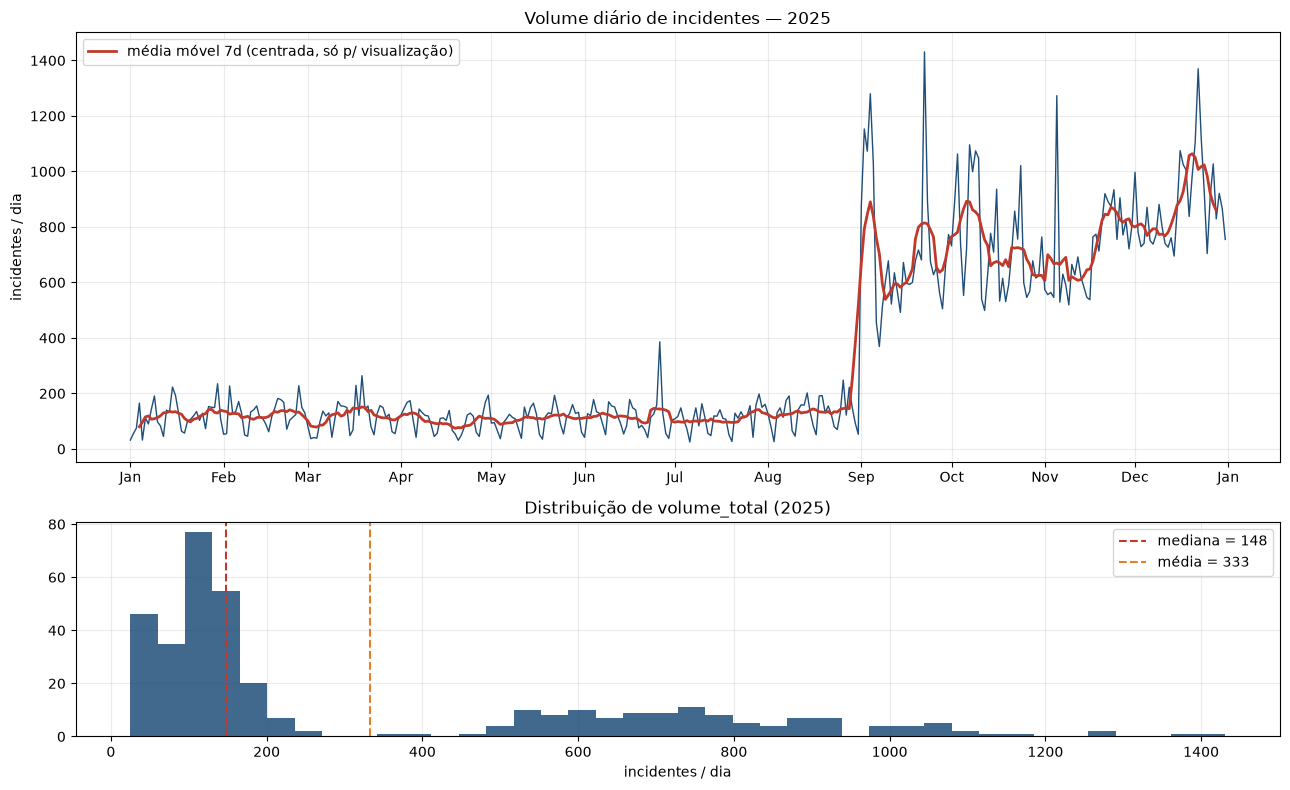

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={"height_ratios": [2, 1]})

ax[0].plot(daily.index, daily["volume_total"], lw=1, color="#1f4e79")
ax[0].plot(daily.index, daily["volume_total"].rolling(7, center=True).mean(),
           lw=2, color="#c0392b", label="média móvel 7d (centrada, só p/ visualização)")
ax[0].set_title("Volume diário de incidentes — 2025")
ax[0].set_ylabel("incidentes / dia")
ax[0].legend(loc="upper left")
ax[0].xaxis.set_major_locator(mdates.MonthLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax[1].hist(daily["volume_total"], bins=40, color="#1f4e79", alpha=0.85)
ax[1].axvline(daily["volume_total"].median(), color="#c0392b", ls="--",
              label=f"mediana = {daily['volume_total'].median():.0f}")
ax[1].axvline(daily["volume_total"].mean(), color="#e67e22", ls="--",
              label=f"média = {daily['volume_total'].mean():.0f}")
ax[1].set_title("Distribuição de volume_total (2025)")
ax[1].set_xlabel("incidentes / dia")
ax[1].legend()
plt.tight_layout()
plt.show()

A distribuição é **fortemente bimodal e assimétrica à direita** (assimetria ≈ 1,1, média muito
acima da mediana). Isso não é um problema de qualidade de dado: são **dois patamares** de
operação colados na mesma série. A Seção 08 separa os dois regimes.

## 08 · Análise da mudança de regime

Hipótese do contexto auditado: a partir de **01/09/2025** há uma **mudança de processo /
instrumentação**, não um aumento operacional real. O volume médio diário salta ~6,6x, e o
salto é quase todo explicado por incidentes `Aberto por = monitoramento`,
`Grupo designado = team14`, `Prioridade = Baixa`.

Os dados **não são removidos** — a quebra é modelada com a variável `periodo_pos_set_2025`
(Seção 09) e discutida nas conclusões.

In [10]:
pre = daily.loc[daily.index < DATA_CORTE_REGIME, "volume_total"]
pos = daily.loc[daily.index >= DATA_CORTE_REGIME, "volume_total"]

comp = pd.DataFrame({
    "pré-set/2025 (jan-ago)": [len(pre), pre.mean(), pre.std(), pre.median(), pre.min(), pre.max()],
    "pós-set/2025 (set-dez)": [len(pos), pos.mean(), pos.std(), pos.median(), pos.min(), pos.max()],
}, index=["n_dias", "média", "desvio", "mediana", "mín", "máx"])
comp["razão pós/pré"] = comp["pós-set/2025 (set-dez)"] / comp["pré-set/2025 (jan-ago)"]
comp.loc["n_dias", "razão pós/pré"] = np.nan  # razão não faz sentido para contagem de dias
print(comp.to_string())
print(f"\nsalto na média diária: {pre.mean():.0f}/dia -> {pos.mean():.0f}/dia "
      f"({pos.mean() / pre.mean():.1f}x)")

         pré-set/2025 (jan-ago)  pós-set/2025 (set-dez)  razão pós/pré
n_dias                  243.000                 122.000            NaN
média                   115.564                 765.598          6.625
desvio                   51.000                 202.535          3.971
mediana                 118.000                 735.000          6.229
mín                      25.000                 369.000         14.760
máx                     386.000               1,431.000          3.707

salto na média diária: 116/dia -> 766/dia (6.6x)


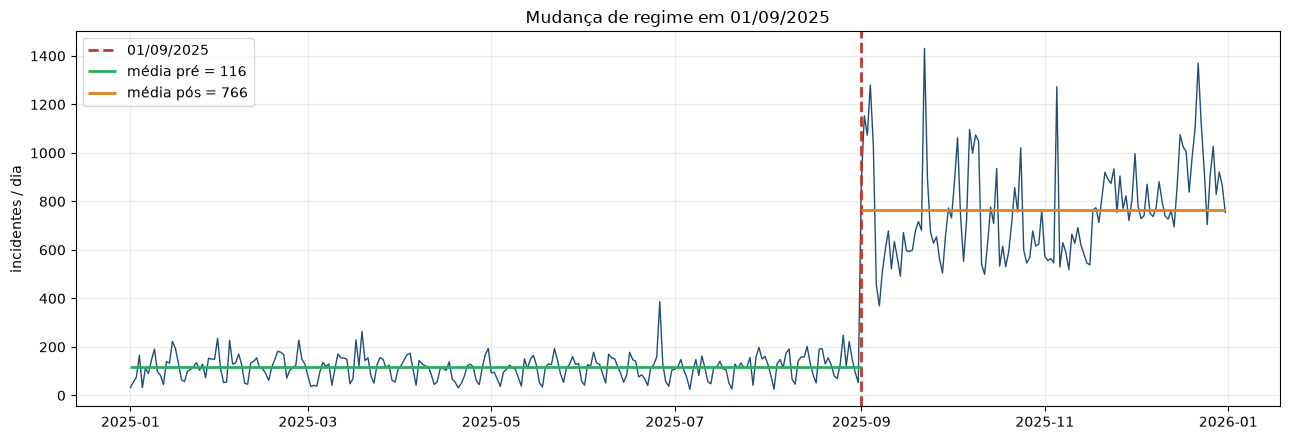

In [11]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily["volume_total"], lw=1, color="#1f4e79")
ax.axvline(DATA_CORTE_REGIME, color="#c0392b", ls="--", lw=2, label="01/09/2025")
ax.hlines(pre.mean(), daily.index.min(), DATA_CORTE_REGIME, color="#27ae60", lw=2,
          label=f"média pré = {pre.mean():.0f}")
ax.hlines(pos.mean(), DATA_CORTE_REGIME, daily.index.max(), color="#e67e22", lw=2,
          label=f"média pós = {pos.mean():.0f}")
ax.set_title("Mudança de regime em 01/09/2025")
ax.set_ylabel("incidentes / dia")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Decomposição do salto: Aberto por x Grupo designado x Prioridade
df["periodo"] = np.where(df["Aberto"] >= DATA_CORTE_REGIME, "pós-set", "pré-set")
prio_nome = {0: "Baixa", 1: "Média", 2: "Alta"}
df["prio_nome"] = df["Prioridade"].map(prio_nome)

print("Incidentes por período x canal de abertura:")
print(pd.crosstab(df["Aberto por"], df["periodo"]).to_string(), "\n")

print("Incidentes por período x canal, restrito a Prioridade = Baixa:")
base_baixa = df[df["Prioridade"] == 0]
print(pd.crosstab(base_baixa["Aberto por"], base_baixa["periodo"]).to_string(), "\n")

print("Incidentes 'monitoramento' por período x grupo designado (top 6):")
mon = df[df["Aberto por"] == "monitoramento"]
tab = pd.crosstab(mon["Grupo designado"], mon["periodo"])
print(tab.sort_values("pós-set", ascending=False).head(6).to_string(), "\n")

alvo = df[(df["Aberto por"] == "monitoramento") & (df["Grupo designado"] == "team14")
          & (df["Prioridade"] == 0)]
print("Incidentes monitoramento + team14 + Prioridade Baixa:")
print(alvo["periodo"].value_counts().to_string())
print(f"\n=> esse recorte único responde por {alvo[alvo['periodo'] == 'pós-set'].shape[0]:,} "
      f"incidentes no pós-set, de um aumento total de "
      f"{len(df[df['periodo']=='pós-set']) - len(df[df['periodo']=='pré-set']):,} incidentes.")

Incidentes por período x canal de abertura:
periodo        pré-set  pós-set
Aberto por                     
manual           12766     4884
monitoramento    15316    88519 

Incidentes por período x canal, restrito a Prioridade = Baixa:


periodo        pré-set  pós-set
Aberto por                     
manual             694      190
monitoramento     5086    58610 

Incidentes 'monitoramento' por período x grupo designado (top 6):
periodo          pré-set  pós-set
Grupo designado                  
team14              8012    80339
team05              3460     3311
team12               456     1422
team10               102     1030
team09               875      731
team03               333      686 

Incidentes monitoramento + team14 + Prioridade Baixa:
periodo
pós-set    57185
pré-set     3772

=> esse recorte único responde por 57,185 incidentes no pós-set, de um aumento total de 65,321 incidentes.


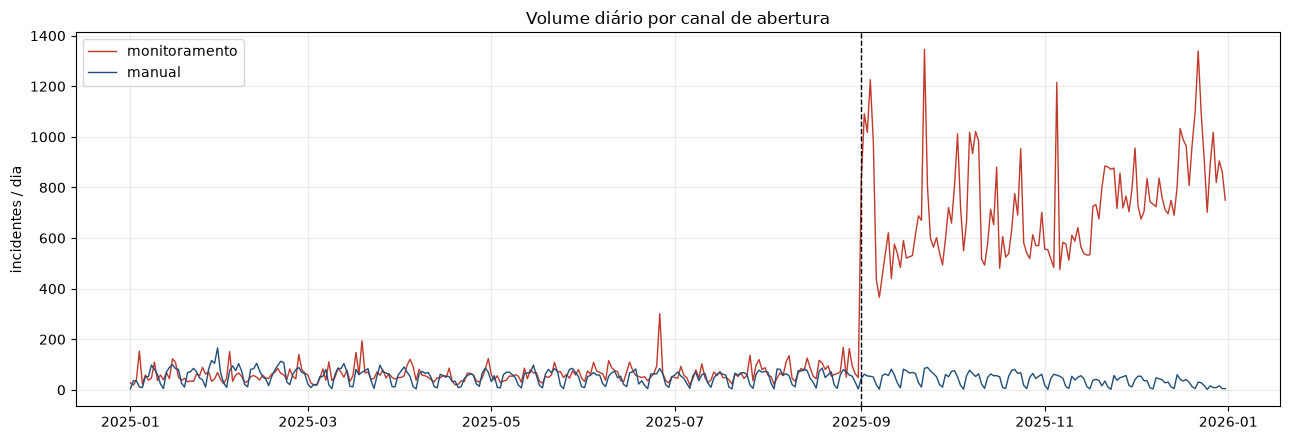

In [13]:
# Volume diário por canal — mostra que o patamar 'manual' é estável e o choque é no monitoramento
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily["volume_monitoramento"], lw=1, color="#c0392b", label="monitoramento")
ax.plot(daily.index, daily["volume_manual"], lw=1, color="#1f4e79", label="manual")
ax.axvline(DATA_CORTE_REGIME, color="k", ls="--", lw=1)
ax.set_title("Volume diário por canal de abertura")
ax.set_ylabel("incidentes / dia")
ax.legend()
plt.tight_layout()
plt.show()

**Leitura:** o canal `manual` mantém patamar estável o ano todo (~30-60/dia). Todo o degrau
está no `monitoramento`, concentrado em `team14` / `Prioridade Baixa`. É a assinatura de uma
**nova fonte de alertas automáticos ligada em set/2025**, não de deterioração operacional.
Consequência para a modelagem: qualquer feature dominada por `volume_p_baixa` ou
`share_monitoramento` vai carregar essa quebra, e o modelo treinado só no pré-set não tem
como antecipar o novo patamar.

## 09 · `periodo_pos_set_2025`

Indicador binário da mudança de regime: `0` antes de 01/09/2025, `1` a partir dessa data.
É a única feature que "sabe" da quebra. Ela será discutida nos dois problemas (D+1 e D+7):
como o split de treino (Seção 14) fica **inteiramente no pré-set**, essa variável é constante
no treino e a Regressão Linear **não consegue estimar seu efeito** — fato central da análise
das Seções 18-19.

In [14]:
daily["periodo_pos_set_2025"] = (daily.index >= DATA_CORTE_REGIME).astype(int)
print(daily["periodo_pos_set_2025"].value_counts().rename("dias").to_string())

periodo_pos_set_2025
0    243
1    122


## 10 · Target D+1

`target_d1 = volume_total.shift(-1)` — a linha do dia $t$ recebe o volume de $t+1$.

In [15]:
daily["target_d1"] = daily["volume_total"].shift(-1)
daily[["volume_total", "target_d1"]].head()

,volume_total,target_d1
data,,
2025-01-01,32,55.000
2025-01-02,55,75.000
2025-01-03,75,165.000
2025-01-04,165,32.000
2025-01-05,32,112.000


## 11 · Target D+7

`target_d7 = volume_total.shift(-7)` — a linha do dia $t$ recebe o volume de $t+7$.

As linhas com target nulo (fim da série) **só serão removidas na Seção 12**, depois de todas
as features de lag/rolling criadas — remover antes deslocaria as janelas.

In [16]:
daily["target_d7"] = daily["volume_total"].shift(-7)
daily[["volume_total", "target_d7"]].tail(9)

,volume_total,target_d7
data,,
2025-12-23,1122,866.000
2025-12-24,929,755.000
2025-12-25,704,NaN
2025-12-26,910,NaN
2025-12-27,1027,NaN
2025-12-28,829,NaN
2025-12-29,921,NaN
2025-12-30,866,NaN
2025-12-31,755,NaN


## 12 · Feature engineering

Cada bloco de feature é justificado antes de ser criado. Regra transversal: **toda** feature
temporal usa `shift()` — nunca o valor do próprio dia-alvo.

### 12.1 Lags de `volume_total`

| feature | tipo | objetivo | vantagem | limitação |
|---|---|---|---|---|
| `lag_1` | lag | volume de ontem; inércia de curtíssimo prazo | prioridade máxima para D+1 | sensível a choques pontuais |
| `lag_2`, `lag_3` | lag | continuidade da tendência recente | suaviza ruído de 1 dia | pouca informação nova sobre lag_1 |
| `lag_7` | lag | mesmo dia da semana anterior | captura sazonalidade semanal; **âncora do D+7** | depende de padrão semanal estável |
| `lag_14` | lag | dia equivalente há 2 semanas | reforça o ciclo semanal | perde 14 linhas iniciais |
| `lag_21`, `lag_28` | lag | ciclo semanal em horizonte longo | prioridade para D+7 (>= 7 dias de folga) | 28 linhas iniciais perdidas; regime pode mudar no intervalo |

`lag_k` para prever $t+1$ usa `volume_total(t+1-k)`; todos com $k\ge 1$ ⇒ informação $\le t$.
Para $t+7$, priorizam-se $k\ge 7$ (o valor mais recente usado é de $t$).

In [17]:
LAGS = [1, 2, 3, 7, 14, 21, 28]
for k in LAGS:
    daily[f"lag_{k}"] = daily["volume_total"].shift(k)

### 12.2 Rolling windows

Implementação segura: `shift(1)` **antes** de `rolling(...)`, para que a janela que termina
"ontem" nunca inclua o dia $t$.

| feature | objetivo | limitação |
|---|---|---|
| `rolling_mean_7` | nível médio da última semana fechada | atrasa mudanças de patamar |
| `rolling_std_7` | volatilidade recente (útil como sinal de instabilidade) | 7 pontos ⇒ estimativa ruidosa |

In [18]:
roll7 = daily["volume_total"].shift(1).rolling(7)
daily["rolling_mean_7"] = roll7.mean()
daily["rolling_std_7"] = roll7.std()

### 12.3 Tendência

`trend_7d` = `rolling_mean_7` de hoje − `rolling_mean_7` de 7 dias atrás. Aproxima a
**inclinação** da série na última semana (positiva = volume subindo). Como `rolling_mean_7`
já é defasada, `trend_7d` também é — não vê o dia $t$.

In [19]:
daily["trend_7d"] = daily["rolling_mean_7"] - daily["rolling_mean_7"].shift(7)

### 12.4 Sazonalidade

Derivadas apenas do calendário do dia $t$ — disponíveis com qualquer antecedência, sem risco
de leakage.

| feature | objetivo | evidência na EDA |
|---|---|---|
| `day_of_week` | efeito de dia útil vs. fim de semana | média cai de ~370 (qua) para ~241 (dom) |
| `is_weekend` | versão binária, mais robusta p/ modelo linear | sáb/dom claramente abaixo |
| `month` | captura deriva mensal / efeito do regime | jan-ago ~3,5k/mês; set-dez >21k/mês |

> `day_of_week` e `month` entram como **inteiros** — sem one-hot/dummies, que ficam para o
> pipeline de modelagem final (fora do escopo deste baseline).

In [20]:
daily["day_of_week"] = daily.index.dayofweek
daily["is_weekend"] = (daily.index.dayofweek >= 5).astype(int)
daily["month"] = daily.index.month

### 12.5 Features diárias contemporâneas (nível/composição do dia $t$)

Medidas fechadas no fim do dia $t$ (Seção 06). São válidas como `Features(t)` porque não
usam nada de $t+1$/$t+7$, mas são **fortemente colineares** com `volume_total(t)` e entre si
— a Seção 19 trata disso explicitamente.

| feature | objetivo | risco |
|---|---|---|
| `volume_p_baixa` / `_media` / `_alta` | nível por severidade hoje | soma = `volume_total`; colinearidade |
| `share_p_baixa` | composição de severidade | anticorrelacionada com as outras shares |
| `share_monitoramento` | peso do canal automático hoje | proxy direta do regime pós-set |
| `share_incidente_pai` | fração vinculada a incidente-pai | interpretação limitada; mantida p/ teste |

Essas features entram como valor **do próprio dia $t$** (são o estado observado no momento
da previsão), então não recebem `shift`.

In [21]:
FEATURES_CONTEMPORANEAS = [
    "volume_p_baixa", "volume_p_media", "volume_p_alta",
    "share_p_baixa", "share_monitoramento", "share_incidente_pai",
]
daily[FEATURES_CONTEMPORANEAS].describe()

,volume_p_baixa,volume_p_media,volume_p_alta,share_p_baixa,share_monitoramento,share_incidente_pai
count,365.000,365.000,365.000,365.000,365.000,365.000
mean,176.932,113.041,42.863,0.367,0.695,0.137
std,228.045,99.829,58.529,0.222,0.221,0.119
min,5.000,6.000,4.000,0.077,0.227,0.000
25%,20.000,62.000,15.000,0.185,0.500,0.055
50%,29.000,85.000,25.000,0.282,0.689,0.102
75%,392.000,130.000,48.000,0.590,0.921,0.185
max,942.000,849.000,684.000,0.856,0.998,0.776


### 12.6 Remoção de linhas com target nulo

**Agora** — depois de todas as features criadas — descartamos apenas o que não tem como ser
usado: linhas sem as features de maior lag (início da série) ou sem target (fim da série).
Mantemos `daily` intacto e trabalhamos sobre cópias por horizonte.

In [22]:
FEATURES_D1 = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7", "trend_7d",
    "day_of_week", "is_weekend", "month",
    "periodo_pos_set_2025",
] + FEATURES_CONTEMPORANEAS

FEATURES_D7 = [
    "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_mean_7", "rolling_std_7", "trend_7d",
    "day_of_week", "is_weekend", "month",
    "periodo_pos_set_2025",
] + FEATURES_CONTEMPORANEAS

ds_d1 = daily.dropna(subset=FEATURES_D1 + ["target_d1"]).copy()
ds_d7 = daily.dropna(subset=FEATURES_D7 + ["target_d7"]).copy()

print(f"D+1: {len(ds_d1)} linhas  ({ds_d1.index.min().date()} a {ds_d1.index.max().date()})")
print(f"D+7: {len(ds_d7)} linhas  ({ds_d7.index.min().date()} a {ds_d7.index.max().date()})")

D+1: 350 linhas  (2025-01-15 a 2025-12-30)
D+7: 330 linhas  (2025-01-29 a 2025-12-24)


## 13 · Auditoria de data leakage

Para cada feature, a janela temporal que ela enxerga e a confirmação de que só usa
informação com `Aberto` $\le$ fim do dia $t$.

In [23]:
leak = pd.DataFrame(
    [
        ("lag_1..lag_28", f"volume_total(t+1-k), k>=1 -> no mínimo t; para D+7 usa-se k>=7",
         "OK: shift(k) com k>=1; nenhum lag toca t+1/t+7"),
        ("rolling_mean_7 / rolling_std_7", "janela [t-7, t-1] (shift(1) antes do rolling(7))",
         "OK: shift(1) garante que o dia t não entra na janela"),
        ("trend_7d", "rolling_mean_7(t) - rolling_mean_7(t-7); ambos já defasados",
         "OK: derivado de features já auditadas como <= t-1"),
        ("day_of_week / is_weekend / month", "calendário do próprio dia t",
         "OK: determinístico, conhecido com qualquer antecedência"),
        ("periodo_pos_set_2025", "indicador de data (t >= 2025-09-01)",
         "OK: a data de t é conhecida; não usa contagem alguma"),
        ("volume_p_baixa/media/alta, share_*", "contagens/frações fechadas no fim do dia t",
         "OK p/ Features(t): não usam t+1/t+7. RESSALVA: colineares com volume_total(t)"),
        ("target_d1 / target_d7", "volume_total(t+1) / volume_total(t+7)",
         "NÃO é feature; nunca entra em X"),
        ("contagem_dia_lag1 (CSV)", "lag sobre a ordem do arquivo bruto (2023/24/25 misturados)",
         "EXCLUÍDA: inválida como informação de t"),
        ("Entrou para KPI?", "SIM/NAO possivelmente definido no fechamento",
         "EXCLUÍDA: disponibilidade em t não confirmada"),
    ],
    columns=["feature", "janela temporal enxergada", "veredito"],
)
leak

,feature,janela temporal enxergada,veredito
0,lag_1..lag_28,"volume_total(t+1-k), k>=1 -> no mínimo t; para...",OK: shift(k) com k>=1; nenhum lag toca t+1/t+7
1,rolling_mean_7 / rolling_std_7,"janela [t-7, t-1] (shift(1) antes do rolling(7))",OK: shift(1) garante que o dia t não entra na ...
2,trend_7d,rolling_mean_7(t) - rolling_mean_7(t-7); ambos...,OK: derivado de features já auditadas como <= t-1
3,day_of_week / is_weekend / month,calendário do próprio dia t,"OK: determinístico, conhecido com qualquer ant..."
4,periodo_pos_set_2025,indicador de data (t >= 2025-09-01),OK: a data de t é conhecida; não usa contagem ...
5,"volume_p_baixa/media/alta, share_*",contagens/frações fechadas no fim do dia t,OK p/ Features(t): não usam t+1/t+7. RESSALVA:...
6,target_d1 / target_d7,volume_total(t+1) / volume_total(t+7),NÃO é feature; nunca entra em X
7,contagem_dia_lag1 (CSV),lag sobre a ordem do arquivo bruto (2023/24/25...,EXCLUÍDA: inválida como informação de t
8,Entrou para KPI?,SIM/NAO possivelmente definido no fechamento,EXCLUÍDA: disponibilidade em t não confirmada


In [24]:
# Checagem programática: nenhuma feature de lag/rolling pode correlacionar-se com o alvo
# mais do que o próprio volume_total(t) deslocado corretamente permitiria.
# Teste direto: reconstruir lag_1 manualmente e comparar.
chk = daily[["volume_total"]].copy()
chk["lag_1_manual"] = [np.nan] + list(daily["volume_total"].values[:-1])
assert np.allclose(chk["lag_1_manual"].values, daily["lag_1"].values, equal_nan=True)

# rolling_mean_7 na data t deve ser igual à média de volume_total em [t-7, t-1]
probe = daily.index[60]
janela = daily.loc[probe - pd.Timedelta(days=7): probe - pd.Timedelta(days=1), "volume_total"]
assert np.isclose(daily.loc[probe, "rolling_mean_7"], janela.mean())
print("checagens de leakage: OK  (lag_1 e rolling_mean_7 reconstruídos manualmente conferem)")

checagens de leakage: OK  (lag_1 e rolling_mean_7 reconstruídos manualmente conferem)


## 14 · Split temporal

Sem `shuffle`, sem `train_test_split` aleatório. Corte por data:

| conjunto | período | papel |
|---|---|---|
| **TRAIN** | jan–ago/2025 | ajuste dos coeficientes |
| **VALIDATION** | set/2025 | primeiro mês do novo regime |
| **TEST** | out–dez/2025 | avaliação final, regime consolidado |

Consequência assumida: TRAIN é **100% pré-regime**; VALIDATION e TEST são **100% pós-regime**.
É o cenário realista de quem treinou um modelo em ago/2025 e enfrentou a virada — e é o que
torna a comparação com o baseline ingênuo informativa.

In [25]:
def split_temporal(frame):
    tr = frame[frame.index < "2025-09-01"]
    va = frame[(frame.index >= "2025-09-01") & (frame.index < "2025-10-01")]
    te = frame[frame.index >= "2025-10-01"]
    return tr, va, te

tr1, va1, te1 = split_temporal(ds_d1)
tr7, va7, te7 = split_temporal(ds_d7)

for nome, tr, va, te in [("D+1", tr1, va1, te1), ("D+7", tr7, va7, te7)]:
    print(f"{nome}:  TRAIN {len(tr):>3} ({tr.index.min().date()}..{tr.index.max().date()}) | "
          f"VAL {len(va):>2} ({va.index.min().date()}..{va.index.max().date()}) | "
          f"TEST {len(te):>3} ({te.index.min().date()}..{te.index.max().date()})")

assert tr1.index.max() < va1.index.min() < te1.index.min()
assert te1.index.min() > va1.index.max()
print("\nordem cronológica TRAIN < VAL < TEST: OK")

D+1:  TRAIN 229 (2025-01-15..2025-08-31) | VAL 30 (2025-09-01..2025-09-30) | TEST  91 (2025-10-01..2025-12-30)
D+7:  TRAIN 215 (2025-01-29..2025-08-31) | VAL 30 (2025-09-01..2025-09-30) | TEST  85 (2025-10-01..2025-12-24)

ordem cronológica TRAIN < VAL < TEST: OK


## 15 · Baseline ingênuo (persistência)

Sem ajuste de parâmetro nenhum:

- **D+1:** `naive_d1(t) = volume_total(t)` — "amanhã = hoje".
- **D+7:** `naive_d7(t) = volume_total(t-6)` — persistência deslocada, conforme especificação.
  Reporto também `naive_d7_sazonal(t) = volume_total(t)` (mesmo dia da semana que $t+7$), que
  é a referência sazonal usual, para contraste.

In [26]:
daily["naive_d1"] = daily["volume_total"]
daily["naive_d7"] = daily["volume_total"].shift(6)
daily["naive_d7_sazonal"] = daily["volume_total"]

# recarrega os naive nos datasets já filtrados
for col in ["naive_d1"]:
    ds_d1[col] = daily.loc[ds_d1.index, col]
for col in ["naive_d7", "naive_d7_sazonal"]:
    ds_d7[col] = daily.loc[ds_d7.index, col]

ds_d1[["volume_total", "naive_d1", "target_d1"]].head()

,volume_total,naive_d1,target_d1
data,,,
2025-01-15,223,223,193.000
2025-01-16,193,193,131.000
2025-01-17,131,131,64.000
2025-01-18,64,64,57.000
2025-01-19,57,57,100.000


## 16 · Regressão Linear — D+1

Treino em TRAIN, seleção em VALIDATION, avaliação final em TEST. Nenhum parâmetro é ajustado
com dados de VAL/TEST — a Regressão Linear não tem hiperparâmetro; VAL serve para leitura
comparativa antes de olhar o TEST.

In [27]:
def treina_lr(tr, va, te, features, target):
    modelo = LinearRegression()
    modelo.fit(tr[features], tr[target])
    pred = {}
    for nome, part in [("TRAIN", tr), ("VAL", va), ("TEST", te)]:
        p = pd.Series(modelo.predict(part[features]), index=part.index)
        pred[nome] = p.clip(lower=0)  # volume não é negativo
    return modelo, pred

lr_d1, pred_lr_d1 = treina_lr(tr1, va1, te1, FEATURES_D1, "target_d1")

resumo_d1 = pd.DataFrame({
    "coef": pd.Series(lr_d1.coef_, index=FEATURES_D1)
}).sort_values("coef", key=abs, ascending=False)
print(f"intercepto: {lr_d1.intercept_:.2f}")
resumo_d1

intercepto: -85.53


,coef
share_p_baixa,189.559
share_monitoramento,125.599
share_incidente_pai,-96.335
is_weekend,-48.559
rolling_mean_7,1.794
volume_p_baixa,-0.727
volume_p_media,0.596
month,0.524
volume_p_alta,0.497
rolling_std_7,-0.407


In [28]:
def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.abs(y_true) + np.abs(y_pred)
    smape = np.mean(np.where(denom == 0, 0.0, 2 * np.abs(y_pred - y_true) / denom)) * 100
    return {"MAE": mae, "RMSE": rmse, "sMAPE_%": smape, "n": len(y_true)}


def tabela_particoes(target_col, series_pred: dict, frame):
    linhas = {}
    for nome, pred in series_pred.items():
        idx = pred.index
        linhas[nome] = metricas(frame.loc[idx, target_col], pred)
    return pd.DataFrame(linhas).T


tab_lr_d1 = tabela_particoes("target_d1", pred_lr_d1, ds_d1)
tab_naive_d1 = tabela_particoes(
    "target_d1",
    {k: ds_d1.loc[v.index, "naive_d1"] for k, v in pred_lr_d1.items()},
    ds_d1,
)
print("D+1 — Regressão Linear:")
print(tab_lr_d1.to_string())
print("\nD+1 — baseline ingênuo (naive_d1 = volume_total(t)):")
print(tab_naive_d1.to_string())

D+1 — Regressão Linear:
          MAE    RMSE  sMAPE_%       n
TRAIN  37.239  64.019   32.141 229.000
VAL   320.433 493.176   59.471  30.000
TEST  239.449 298.440   35.394  91.000

D+1 — baseline ingênuo (naive_d1 = volume_total(t)):
          MAE    RMSE  sMAPE_%       n
TRAIN  47.524  80.202   41.308 229.000
VAL   155.133 231.583   20.046  30.000
TEST  133.396 187.976   16.572  91.000


## 17 · Regressão Linear — D+7

Mesma lógica, com o conjunto de features de lag longo (`lag_7..28`).

In [29]:
lr_d7, pred_lr_d7 = treina_lr(tr7, va7, te7, FEATURES_D7, "target_d7")

print(f"intercepto: {lr_d7.intercept_:.2f}")
tab_lr_d7 = tabela_particoes("target_d7", pred_lr_d7, ds_d7)
tab_naive_d7 = tabela_particoes(
    "target_d7",
    {k: ds_d7.loc[v.index, "naive_d7"] for k, v in pred_lr_d7.items()},
    ds_d7,
)
tab_naive_d7_saz = tabela_particoes(
    "target_d7",
    {k: ds_d7.loc[v.index, "naive_d7_sazonal"] for k, v in pred_lr_d7.items()},
    ds_d7,
)
print("D+7 — Regressão Linear:")
print(tab_lr_d7.to_string())
print("\nD+7 — baseline ingênuo (naive_d7 = volume_total(t-6)):")
print(tab_naive_d7.to_string())
print("\nD+7 — referência sazonal (naive = volume_total(t), mesmo dia da semana que t+7):")
print(tab_naive_d7_saz.to_string())

intercepto: -510.03
D+7 — Regressão Linear:
            MAE      RMSE  sMAPE_%       n
TRAIN    74.031   133.989   54.415 215.000
VAL   1,650.443 1,728.113  106.389  30.000
TEST  2,689.326 2,709.559  127.186  85.000

D+7 — baseline ingênuo (naive_d7 = volume_total(t-6)):
          MAE    RMSE  sMAPE_%       n
TRAIN  70.195 162.165   47.104 215.000
VAL   327.067 394.131   54.408  30.000
TEST  182.294 231.269   22.971  85.000

D+7 — referência sazonal (naive = volume_total(t), mesmo dia da semana que t+7):
          MAE    RMSE  sMAPE_%       n
TRAIN  56.842 151.044   33.232 215.000
VAL   238.433 324.749   30.150  30.000
TEST  151.941 209.188   18.472  85.000


In [30]:
pd.Series(lr_d7.coef_, index=FEATURES_D7).sort_values(key=abs, ascending=False).to_frame("coef")

,coef
share_incidente_pai,54.779
share_monitoramento,32.703
share_p_baixa,28.971
month,19.522
is_weekend,-9.618
rolling_mean_7,3.387
trend_7d,-1.841
volume_p_baixa,1.162
rolling_std_7,-0.563
volume_p_media,0.496


## 18 · Métricas por recorte temporal

MAE, RMSE e sMAPE — **não** MAPE puro: o volume mínimo diário é 25, baixo o bastante para
inflar erros percentuais. Reportado para baseline ingênuo e Regressão Linear, D+1 e D+7, em
três recortes de 2025:

- **(a) série completa** — todas as linhas com features + target válidos;
- **(b) somente pré-set/2025** — datas-alvo antes de 01/09/2025;
- **(c) somente pós-set/2025** — datas-alvo em 01/09/2025 ou depois.

O modelo é ajustado **só no TRAIN** (pré-set). Prever sobre toda a série e recortar mostra o
que é desempenho "dentro do regime de treino" (b) vs. "fora dele" (c).

In [31]:
def preditor_lr(modelo, frame, features):
    return pd.Series(modelo.predict(frame[features]), index=frame.index).clip(lower=0)


def avalia_recortes(frame, target_col, pred_full: pd.Series, naive_col: str):
    recortes = {
        "(a) 2025 completo": frame.index,
        "(b) pré-set/2025": frame.index[frame.index < DATA_CORTE_REGIME],
        "(c) pós-set/2025": frame.index[frame.index >= DATA_CORTE_REGIME],
    }
    out = []
    for nome, idx in recortes.items():
        if len(idx) == 0:
            continue
        m_lr = metricas(frame.loc[idx, target_col], pred_full.loc[idx])
        m_nv = metricas(frame.loc[idx, target_col], frame.loc[idx, naive_col])
        out.append((nome, "Regressão Linear", *m_lr.values()))
        out.append((nome, "Baseline ingênuo", *m_nv.values()))
    return pd.DataFrame(out, columns=["recorte", "modelo", "MAE", "RMSE", "sMAPE_%", "n"])


pred_full_d1 = preditor_lr(lr_d1, ds_d1, FEATURES_D1)
pred_full_d7 = preditor_lr(lr_d7, ds_d7, FEATURES_D7)

painel_d1 = avalia_recortes(ds_d1, "target_d1", pred_full_d1, "naive_d1")
painel_d7 = avalia_recortes(ds_d7, "target_d7", pred_full_d7, "naive_d7")

print("=== D+1 ===")
print(painel_d1.to_string(index=False))
print("\n=== D+7 ===")
print(painel_d7.to_string(index=False))

=== D+1 ===
          recorte           modelo     MAE    RMSE  sMAPE_%   n
(a) 2025 completo Regressão Linear 114.087 216.071   35.329 350
(a) 2025 completo Baseline ingênuo  79.074 134.137   33.054 350
 (b) pré-set/2025 Regressão Linear  37.239  64.019   32.141 229
 (b) pré-set/2025 Baseline ingênuo  47.524  80.202   41.308 229
 (c) pós-set/2025 Regressão Linear 259.527 356.773   41.364 121
 (c) pós-set/2025 Baseline ingênuo 138.785 199.678   17.433 121

=== D+7 ===
          recorte           modelo       MAE      RMSE  sMAPE_%   n
(a) 2025 completo Regressão Linear   890.978 1,474.528   77.884 330
(a) 2025 completo Baseline ingênuo   122.421   212.206   41.552 330
 (b) pré-set/2025 Regressão Linear    74.031   133.989   54.415 215
 (b) pré-set/2025 Baseline ingênuo    70.195   162.165   47.104 215
 (c) pós-set/2025 Regressão Linear 2,418.313 2,491.092  121.761 115
 (c) pós-set/2025 Baseline ingênuo   220.061   282.941   31.172 115


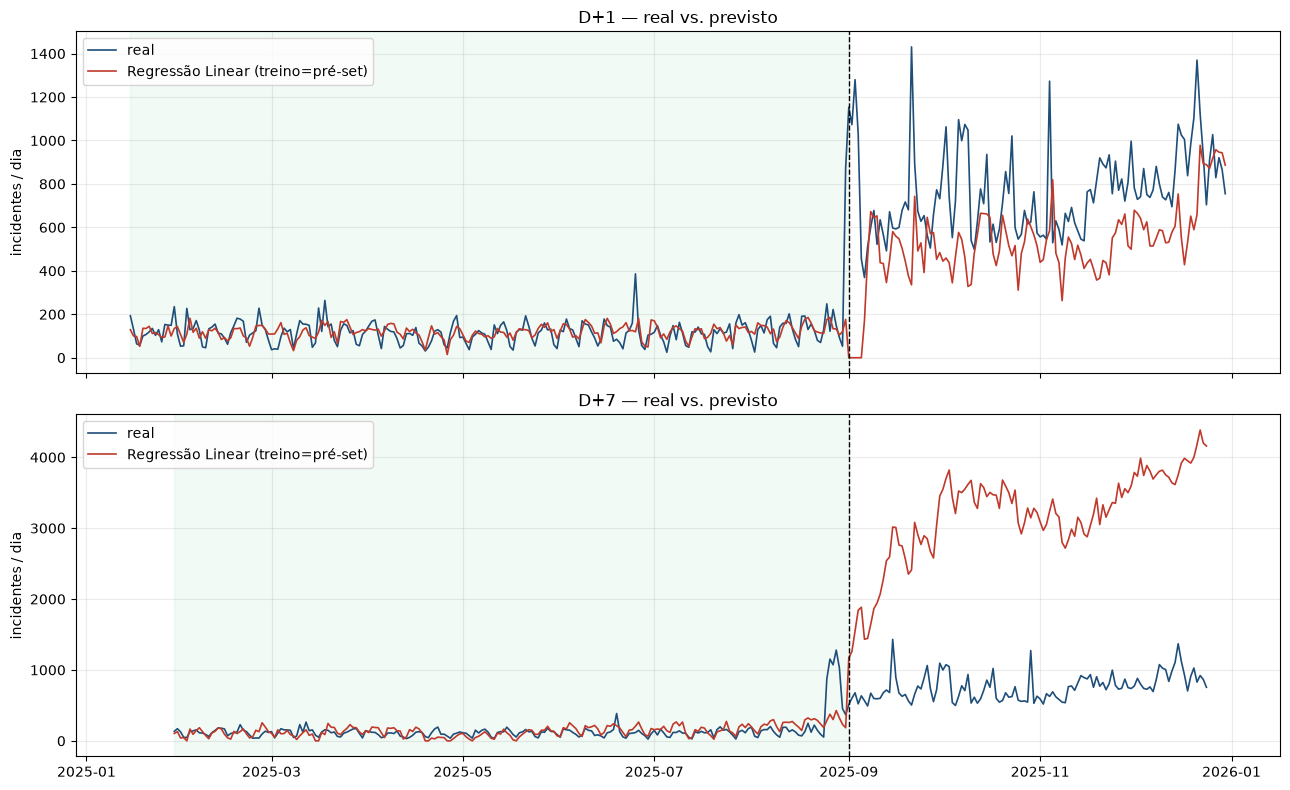

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, ds, target, pred, titulo in [
    (axes[0], ds_d1, "target_d1", pred_full_d1, "D+1"),
    (axes[1], ds_d7, "target_d7", pred_full_d7, "D+7"),
]:
    ax.plot(ds.index, ds[target], color="#1f4e79", lw=1.2, label="real")
    ax.plot(ds.index, pred, color="#c0392b", lw=1.2, label="Regressão Linear (treino=pré-set)")
    ax.axvline(DATA_CORTE_REGIME, color="k", ls="--", lw=1)
    ax.axvspan(ds.index.min(), pd.Timestamp("2025-09-01"), color="#27ae60", alpha=0.06)
    ax.set_title(f"{titulo} — real vs. previsto")
    ax.set_ylabel("incidentes / dia")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

O modelo linear treinado no pré-set **não acompanha o degrau**: no recorte (c) o erro explode
para os dois horizontes. É o comportamento esperado e o principal achado do baseline — ver
Seções 19-20.

## 19 · Análise das features

In [33]:
coef_d1 = pd.Series(lr_d1.coef_, index=FEATURES_D1, name="coef_D1")
coef_d7 = pd.Series(lr_d7.coef_, index=FEATURES_D7, name="coef_D7")
painel_coef = pd.concat([coef_d1, coef_d7], axis=1)
painel_coef["|coef_D1|"] = painel_coef["coef_D1"].abs()
painel_coef.sort_values("|coef_D1|", ascending=False).drop(columns="|coef_D1|")

,coef_D1,coef_D7
share_p_baixa,189.559,28.971
share_monitoramento,125.599,32.703
share_incidente_pai,-96.335,54.779
is_weekend,-48.559,-9.618
rolling_mean_7,1.794,3.387
volume_p_baixa,-0.727,1.162
volume_p_media,0.596,0.496
month,0.524,19.522
volume_p_alta,0.497,0.236
rolling_std_7,-0.407,-0.563


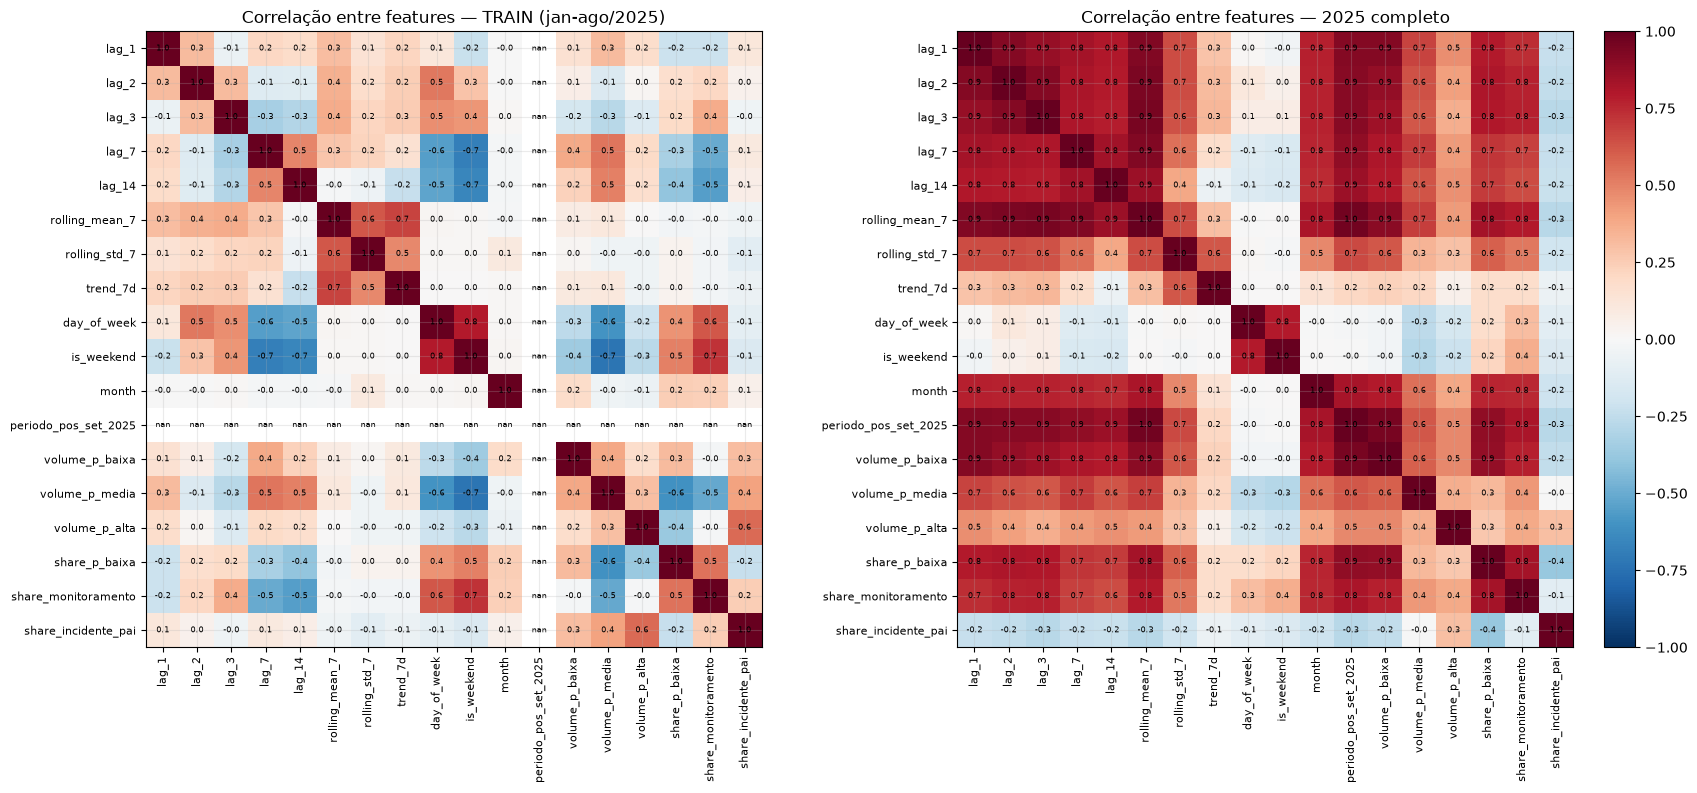

In [34]:
# Colinearidade: a mesma matriz de correlação calculada só no TRAIN (pré-regime)
# e sobre toda a série 2025 (com o regime pós-set).
corr_tr = tr1[FEATURES_D1].corr()
corr_full = ds_d1[FEATURES_D1].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, mat, titulo in [(axes[0], corr_tr, "TRAIN (jan-ago/2025)"),
                        (axes[1], corr_full, "2025 completo")]:
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(FEATURES_D1)))
    ax.set_xticklabels(FEATURES_D1, rotation=90, fontsize=8)
    ax.set_yticks(range(len(FEATURES_D1)))
    ax.set_yticklabels(FEATURES_D1, fontsize=8)
    for i in range(len(FEATURES_D1)):
        for j in range(len(FEATURES_D1)):
            ax.text(j, i, f"{mat.iloc[i, j]:.1f}", ha="center", va="center", fontsize=6)
    ax.set_title(f"Correlação entre features — {titulo}")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
plt.show()

In [35]:
def pares_altos(mat, limite=0.85):
    m = mat.where(np.triu(np.ones(mat.shape), k=1).astype(bool)).stack().rename("r")
    out = m[m.abs() > limite].sort_values(key=abs, ascending=False)
    out.index = [f"{a} x {b}" for a, b in out.index]
    return out

alto_tr = pares_altos(corr_tr)
alto_full = pares_altos(corr_full)
print("Pares com |r| > 0,85 — TRAIN (pré-regime):")
print(alto_tr.to_string() if len(alto_tr) else "  (nenhum — modelo linear bem condicionado no pré-set)")
print("\nPares com |r| > 0,85 — 2025 completo (com regime pós-set):")
print(alto_full.to_string() if len(alto_full) else "  (nenhum)")

print("\nperiodo_pos_set_2025 — valores distintos por partição (D+1):")
print(f"  TRAIN={tr1['periodo_pos_set_2025'].unique()}  "
      f"VAL={va1['periodo_pos_set_2025'].unique()}  "
      f"TEST={te1['periodo_pos_set_2025'].unique()}")

Pares com |r| > 0,85 — TRAIN (pré-regime):
  (nenhum — modelo linear bem condicionado no pré-set)

Pares com |r| > 0,85 — 2025 completo (com regime pós-set):
rolling_mean_7 x periodo_pos_set_2025   0.962
periodo_pos_set_2025 x volume_p_baixa   0.948
lag_3 x rolling_mean_7                  0.946
lag_2 x rolling_mean_7                  0.939
lag_1 x rolling_mean_7                  0.926
lag_7 x rolling_mean_7                  0.924
lag_1 x volume_p_baixa                  0.919
lag_1 x periodo_pos_set_2025            0.919
lag_1 x lag_2                           0.918
lag_2 x lag_3                           0.918
lag_2 x periodo_pos_set_2025            0.912
lag_3 x periodo_pos_set_2025            0.906
rolling_mean_7 x volume_p_baixa         0.900
periodo_pos_set_2025 x share_p_baixa    0.890
lag_7 x periodo_pos_set_2025            0.887
volume_p_baixa x share_p_baixa          0.881
lag_2 x volume_p_baixa                  0.878
lag_1 x lag_3                           0.868
lag_14 x rolli

**Leitura dos coeficientes e da colinearidade:**

- **`periodo_pos_set_2025` não tem efeito estimável no baseline atual.** No TRAIN ela é
  constante (`0`); em VAL e TEST é constante (`1`). Nenhuma partição tem variação, então a
  Regressão Linear não separa o efeito do regime do intercepto — o coeficiente estimado não
  é interpretável. A variável só ganharia poder com uma janela de treino que **atravessasse**
  01/09/2025. Este é o motivo concreto de o modelo não prever o degrau.
- **A colinearidade é dirigida pelo regime.** No TRAIN (série estável) o par mais
  correlacionado é `day_of_week`×`is_weekend` (~0,79) e os lags entre si ficam abaixo de
  0,85 — o modelo linear no pré-set está razoavelmente condicionado. Já em 2025 **completo**,
  `lag_1/lag_2/lag_3`, `lag_7`, `rolling_mean_7` e `volume_p_baixa` formam um bloco com
  r ≈ 0,9-0,95: o degrau de set/2025 move todas essas variáveis juntas. Ou seja, a
  redundância dessas features é um artefato da quebra, não uma propriedade estrutural da
  série — e um modelo treinado sobre os dois regimes herda essa colinearidade.
- **`volume_p_baixa` e `share_monitoramento` são proxies do regime.**
  `volume_p_baixa` + `volume_p_media` + `volume_p_alta` = `volume_total` por construção, e a
  quase totalidade do degrau está em `volume_p_baixa`; `share_monitoramento` passa de ~0,5-0,7
  para ~0,9 na virada. Elas descrevem *o que já aconteceu no dia t*, não antecipam t+1 — e
  arrastam a quebra para dentro de qualquer análise de importância.
- **`rolling_mean_7`** é o preditor de nível mais estável e honesto (média da semana fechada);
  **`rolling_std_7`** e **`trend_7d`** disparam na transição — servem como sinal de
  instabilidade, com atraso.
- **Sazonais:** `is_weekend` tem efeito coerente e pequeno (domingo ~35% abaixo da média de
  dia útil); `day_of_week` como inteiro impõe uma ordem linear artificial (segunda<...<domingo);
  `month` como inteiro vira um contador de data correlacionado com o regime — nenhum dos dois
  captura ciclo de forma limpa num modelo linear.

## 20 · Conclusões

### O que o baseline mostrou (com números)

1. **A quebra de 01/09/2025 domina tudo.** Média diária 116 → 766 (6,6x), toda no canal
   `monitoramento` / `team14` / `Prioridade Baixa` (~57 mil incidentes num único recorte).
   Tratada como mudança de instrumentação, não de demanda real (Seção 08).
2. **Baseline ingênuo vs. Regressão Linear (Seção 18):**
   - **D+1, pré-set:** a LR bate a persistência (MAE ~37 vs ~48; sMAPE ~32% vs ~41%) — as
     features de lag/rolling carregam sinal real quando o regime é estável.
   - **D+1, pós-set:** a ordem se inverte — a persistência fica bem melhor (sMAPE ~17% vs
     ~41%); a LR treinada no pré-set extrapola para baixo.
   - **D+7:** no pré-set LR e naive empatam (MAE ~74 vs ~70); no pós-set a LR **colapsa**
     (MAE > 2.400, sMAPE > 120%) — regressão linear extrapola sem limite num degrau de 6,6x.
   Conclusão: o baseline ingênuo *por regime* é um competidor sério; qualquer modelo futuro
   precisa bater a persistência **dentro de cada regime**, nunca na série 2025 misturada.
3. **`periodo_pos_set_2025` não teve efeito estimável** porque nenhuma partição do split
   contém os dois regimes. A variável é necessária, mas só funciona com janela de treino que
   atravesse a virada.

### Features com potencial preditivo real

- `lag_1` (D+1): melhor sinal de curto prazo — sustenta a vantagem da LR no D+1 pré-set.
- `lag_7` (D+1 e D+7): âncora de sazonalidade semanal; único lag "seguro" para o horizonte D+7.
- `rolling_mean_7`: preditor de nível mais estável e sem leakage; candidato natural a feature
  central do modelo final.
- `is_weekend`: efeito de calendário pequeno mas consistente (domingo ~35% abaixo do dia útil).
- `rolling_std_7` / `trend_7d`: úteis como **detectores de mudança de regime**, não como
  preditores de nível.

### Features a descartar ou reformular

- `lag_2`, `lag_3`: no pré-set acrescentam pouco sobre `lag_1`; no 2025 completo entram no
  bloco colinear r≈0,9 (Seção 19). Manter no máximo uma, ou substituir por `rolling_mean_3`.
- `volume_p_baixa`, `share_monitoramento`: descrevem o dia `t` já fechado e concentram a
  quebra; não antecipam `t+1`. Tirar do baseline de nível — servem, no máximo, como entrada
  de um classificador de regime.
- `day_of_week` e `month` como inteiros: impõem ordem/escala artificial num modelo linear.
  Reformular como par `sin/cos` ou, no caso de `month`, remover (virou proxy de data).
- `share_incidente_pai`, `share_p_media`, `share_p_alta`: sem sinal claro no baseline;
  reavaliar só com o modelo final.
- `contagem_dia_lag1` (CSV) e `Entrou para KPI?`: fora, pelas razões das Seções 04 e 13.

### Recomendações para o próximo sprint

1. **Detectar/segmentar regime antes de prever nível.** Ou treinar um modelo por regime, ou
   incluir a virada na janela de treino (walk-forward com origem móvel) para que
   `periodo_pos_set_2025` e as interações regime×lag sejam estimáveis.
2. **Validação walk-forward** (janela deslizante com re-treino), não um único corte — para
   medir a capacidade de adaptação a mudanças de patamar, que é o risco real desta série.
3. **Manter o baseline ingênuo por regime como métrica de referência** em todo experimento
   futuro; reportar sempre MAE/RMSE/sMAPE separados por regime.
4. **Explorar a dimensão multivariada** que este baseline deixou de fora (Produto/Categoria/
   Grupo) só depois de resolver o problema de missing (~64%) — provavelmente com um modelo
   hierárquico ou com features de volume por grupo (ex.: `volume_team14_lag_7`), que é onde
   está a variância.
5. **Modelo final não-linear** (árvores/boosting) tende a lidar melhor com a quebra e com a
   colinearidade das features de composição — mas só com o esquema de validação do item 2.